# Generative Adversarial Network (GAN) in 2D

In this tutorial, we will use **Nanograd** to build and train a **Least Squares Generative Adversarial Network (LSGAN)** in 2D. 

GANs are a class of machine learning frameworks where two neural networks contest with each other in a game:
1. **The Generator ($G$)**: Learns to generate realistic data starting from random noise.
2. **The Discriminator ($D$)**: Learns to distinguish between real data (from our training set) and fake data (generated by $G$).

Instead of binary cross-entropy (which can suffer from vanishing gradients), we will implement a **Least Squares GAN (LSGAN)**. In LSGAN, the objective functions are based on Mean Squared Error (MSE), which stabilizes training and works beautifully for 2D distributions.

We will train the generator to map 2D random noise into coordinates representing a **circular ring**, and watch the generator's outputs morph from random noise into a geometric shape over epochs.

---

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from nanograd import Tensor, MLP
from nanograd.loss import MSE
from nanograd.optim import Adam

np.random.seed(42)

## 1. Defining the Target Real Distribution

Our target real distribution is a circle with a radius of $1.0$ and slight Gaussian noise.

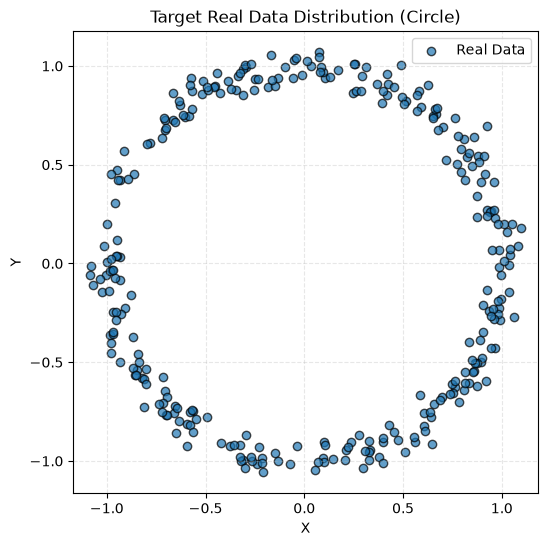

In [2]:
def sample_real_data(batch_size=128):
    theta = np.random.uniform(0, 2 * np.pi, size=(batch_size, 1))
    r = 1.0
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    # Add minor noise
    data = np.hstack([x, y]) + np.random.normal(0, 0.05, size=(batch_size, 2))
    return data

def sample_noise(batch_size=128):
    # Standard normal latent noise
    return np.random.normal(0, 1.0, size=(batch_size, 2))

# Visualize real data distribution
real_samples = sample_real_data(300)
plt.figure(figsize=(6, 6))
plt.scatter(real_samples[:, 0], real_samples[:, 1], color='#1f77b4', alpha=0.7, edgecolors='k', label='Real Data')
plt.title('Target Real Data Distribution (Circle)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.show()

## 2. Defining Generator and Discriminator

- **Generator**: takes 2D noise $\sim \mathcal{N}(0, I)$ and outputs a 2D coordinate $(x_{fake}, y_{fake})$.
- **Discriminator**: takes a 2D coordinate $(x, y)$ and outputs a single scalar logit predicting whether the input is real ($1.0$) or fake ($0.0$).

We manually override the last layer activations to identity (linear output) and apply He normal initialization.

In [3]:
# Generator: 2D noise -> 16 hidden -> 16 hidden -> 2D output coordinate
net_G = MLP([2, 16, 16, 2])
net_G.layers[-1].activation_function = lambda x: x

# Discriminator: 2D coordinate -> 16 hidden -> 16 hidden -> 1D output prediction
net_D = MLP([2, 16, 16, 1])
net_D.layers[-1].activation_function = lambda x: x

# Apply He initialization
for layer in net_G.layers + net_D.layers:
    layer.weights.data = np.random.normal(0, np.sqrt(2.0 / layer.num_inputs), size=layer.weights.data.shape)
    layer.bias.data = np.zeros(layer.bias.data.shape)

# Separate optimizers
opt_G = Adam(net_G.params(), learning_rate=0.01)
opt_D = Adam(net_D.params(), learning_rate=0.005)

criterion = MSE()

## 3. Training Loop (Adversarial Training)

We train the model for 300 epochs. In each epoch we:
1. **Train D**: Minimize $0.5 \cdot \text{MSE}(D(x_{real}), 1) + 0.5 \cdot \text{MSE}(D(G(z)), 0)$. We detach the generated points so gradient doesn't flow back to $G$ while updating $D$.
2. **Train G**: Minimize $0.5 \cdot \text{MSE}(D(G(z)), 1)$, meaning $G$ tries to trick $D$ into outputting $1.0$.

We will record the generator's outputs at intermediate epochs to visualize the learning progress.

In [4]:
epochs = 300
batch_size = 128

# We will save generator samples at these epochs
viz_epochs = [0, 50, 100, 200, 300]
history_samples = {}

d_losses = []
g_losses = []

print("Starting Adversarial Training...")
for epoch in range(epochs + 1):
    # --- Train Discriminator ---
    real_data = sample_real_data(batch_size)
    noise = sample_noise(batch_size)
    
    x_real = Tensor(real_data)
    z = Tensor(noise)
    
    x_fake = net_G(z)
    # Detach x_fake's gradient path to avoid updating G when training D
    x_fake_detached = Tensor(x_fake.data)
    
    d_real = net_D(x_real)
    d_fake = net_D(x_fake_detached)
    
    # LSGAN Discriminator objective
    loss_D_real = criterion(d_real, Tensor(np.ones((batch_size, 1))))
    loss_D_fake = criterion(d_fake, Tensor(np.zeros((batch_size, 1))))
    loss_D = (loss_D_real + loss_D_fake) * 0.5
    
    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()
    
    # --- Train Generator ---
    noise = sample_noise(batch_size)
    z = Tensor(noise)
    
    x_fake = net_G(z)
    d_fake = net_D(x_fake)
    
    # LSGAN Generator objective
    loss_G = criterion(d_fake, Tensor(np.ones((batch_size, 1)))) * 0.5
    
    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()
    
    # Record progress
    d_losses.append(loss_D.data.item())
    g_losses.append(loss_G.data.item())
    
    # Save snapshots for visualization
    if epoch in viz_epochs:
        test_z = Tensor(sample_noise(300))
        gen_points = net_G(test_z).data
        history_samples[epoch] = gen_points
        
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | D Loss: {loss_D.data.item():.5f} | G Loss: {loss_G.data.item():.5f}")

Starting Adversarial Training...
Epoch   0/300 | D Loss: 0.56684 | G Loss: 0.27134
Epoch  50/300 | D Loss: 0.18639 | G Loss: 0.25403
Epoch 100/300 | D Loss: 0.20996 | G Loss: 0.34638
Epoch 150/300 | D Loss: 0.16707 | G Loss: 0.21685
Epoch 200/300 | D Loss: 0.33714 | G Loss: 0.31733
Epoch 250/300 | D Loss: 0.09985 | G Loss: 0.25942
Epoch 300/300 | D Loss: 0.18514 | G Loss: 0.21524


## 4. Visualizing Training Snaphots (Morphing Sequence)

Let's see how our generator learned to shape points from a random normal cluster to the circular ring!

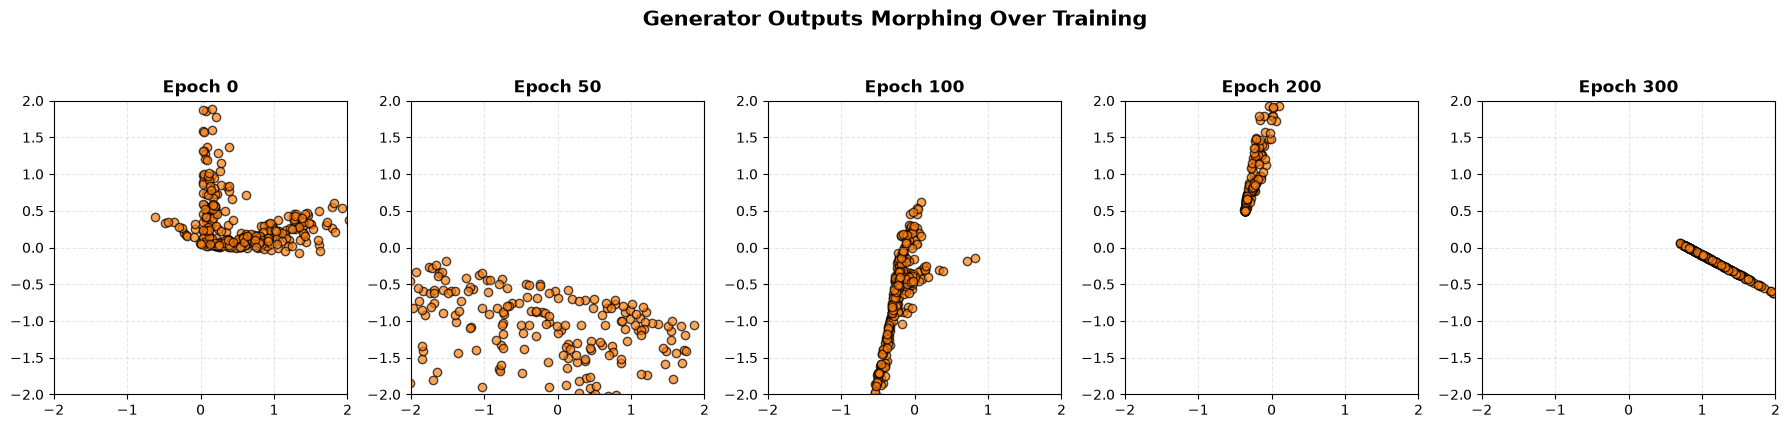

In [5]:
fig, axes = plt.subplots(1, len(viz_epochs), figsize=(18, 4))

for i, epoch in enumerate(viz_epochs):
    points = history_samples[epoch]
    axes[i].scatter(points[:, 0], points[:, 1], color='#ff7f0e', alpha=0.7, edgecolors='k')
    axes[i].set_title(f"Epoch {epoch}", fontsize=12, fontweight='bold')
    axes[i].set_xlim(-2.0, 2.0)
    axes[i].set_ylim(-2.0, 2.0)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].set_aspect('equal')

plt.suptitle("Generator Outputs Morphing Over Training", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 5. Plotting Adversarial Loss Curves

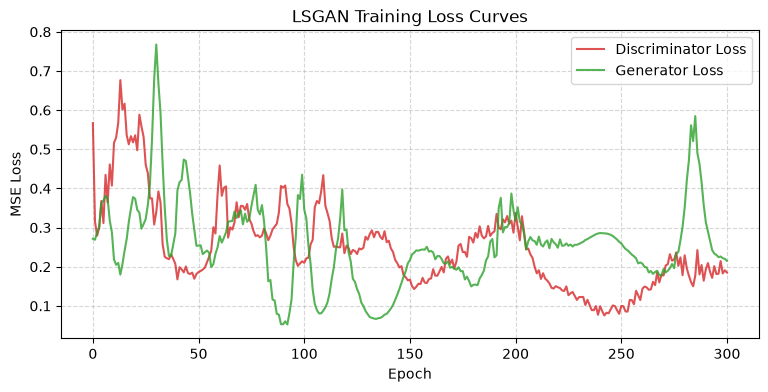

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(d_losses, label='Discriminator Loss', color='#d62728', alpha=0.8)
plt.plot(g_losses, label='Generator Loss', color='#2ca02c', alpha=0.8)
plt.title('LSGAN Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()